# Examples

## Text Analysis

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.corpora import Dictionary
nltk.download('punkt_tab')
nltk.download('stopwords')
# Sample reviews
review1 = "The TechTrend X1 camera captures stunning photos, but the battery life could be better. I'm very impressed with the camera quality."
review2 = "I'm disappointed with the TechTrend X1 battery life, although the camera quality is exceptional. However, the camera features are lacking."
# Tokenization
tokens1 = word_tokenize(review1)
tokens2 = word_tokenize(review2)
# Stop word removal
stop_words = set(stopwords.words('english'))
filtered_tokens1 = [word for word in tokens1 if word.lower() not in stop_words]
filtered_tokens2 = [word for word in tokens2 if word.lower() not in stop_words]
# Create dictionary
documents = [filtered_tokens1, filtered_tokens2]
dictionary = Dictionary(documents)
# Generate bag-of-words vectors
bow_vector1 = dictionary.doc2bow(filtered_tokens1)
bow_vector2 = dictionary.doc2bow(filtered_tokens2)
# Print results
print("Filtered Tokens 1:", filtered_tokens1)
print("Filtered Tokens 2:", filtered_tokens2)
print("Dictionary:", dictionary.token2id)
print("BoW Vector 1:", bow_vector1)
print("BoW Vector 2:", bow_vector2)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Filtered Tokens 1: ['TechTrend', 'X1', 'camera', 'captures', 'stunning', 'photos', ',', 'battery', 'life', 'could', 'better', '.', "'m", 'impressed', 'camera', 'quality', '.']
Filtered Tokens 2: ["'m", 'disappointed', 'TechTrend', 'X1', 'battery', 'life', ',', 'although', 'camera', 'quality', 'exceptional', '.', 'However', ',', 'camera', 'features', 'lacking', '.']
Dictionary: {"'m": 0, ',': 1, '.': 2, 'TechTrend': 3, 'X1': 4, 'battery': 5, 'better': 6, 'camera': 7, 'captures': 8, 'could': 9, 'impressed': 10, 'life': 11, 'photos': 12, 'quality': 13, 'stunning': 14, 'However': 15, 'although': 16, 'disappointed': 17, 'exceptional': 18, 'features': 19, 'lacking': 20}
BoW Vector 1: [(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1)]
BoW Vector 2: [(0, 1), (1, 2), (2, 2), (3, 1), (4, 1), (5, 1), (7, 2), (11, 1), (13, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]


## Stopwords and Wordcloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


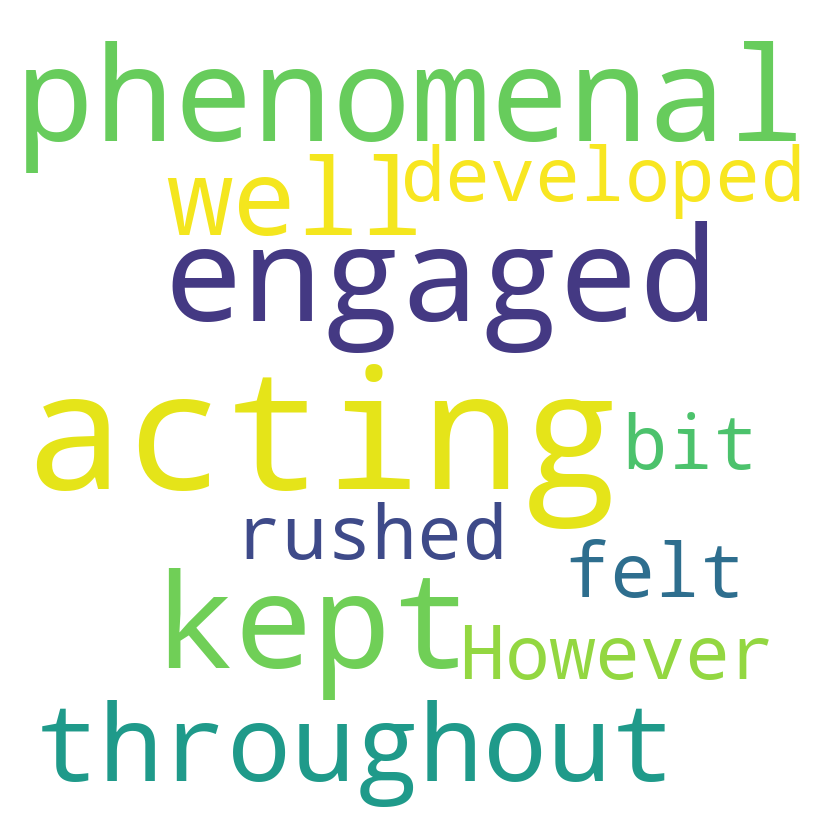

In [3]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('stopwords')
text = "The acting in this movie was phenomenal! The plot kept me engaged throughout, and the characters were well-developed. However, the ending felt a bit rushed."
words = text.split()
stop_words = set(stopwords.words('english'))
custom_stopwords = {'movie', 'plot', 'characters', 'ending'}  # Example custom stopwords
stop_words.update(custom_stopwords)
filtered_words = [word for word in words if word.lower() not in stop_words]
filtered_text = ' '.join(filtered_words)

wordcloud = WordCloud(width=800, height=800,
                      background_color='white',
                      stopwords=stop_words,
                      min_font_size=10).generate(filtered_text)
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

## Sparse and Dense BOW

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

Below a sparse representation of documents is shown, where the vector representation of each document contains many zeros. In the case below this is not toobad, but as the document size and vocabulary size increases this can get out of hand quickly.

In [6]:
documents = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?"
]
vectorizer = CountVectorizer()
sparse_bow = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()
print(sparse_bow.toarray())
print("Feature Names:", feature_names)

[[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]
Feature Names: ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']


Another option is to use dense representations where the goal is to not waste any spase in the representation. For this we'll use the ubiquitous Word2Vec model. This model embeds words into a 300 dimensional vector space of continuous values. This sounds like a lot, but remember that there are over 1.000.000 words in the english language and the sparse representation would be much larger. Even though the encoding could be done more efficiently due to the use of integers instead of floating point values.

In [7]:
import gensim.downloader as api
word_vectors = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [10]:
words = ["king", "queen", "man", "woman"]
dense_bow = [word_vectors[word] for word in words]
print(dense_bow[0].shape)

(300,)


In [17]:
dense_bow[0].dot(dense_bow[1] - dense_bow[3] + dense_bow[2])

np.float32(6.270735)

## Similarity measures in recommender systems

In [23]:
import numpy as np
import pandas as pd
from sklearn. metrics.pairwise import cosine_similarity
# Define the documents and their contents
documents = {
    "Document 1": "Political unrest leads to protests.",
    "Document 2": "New technology breakthrough announced.",
    "Document 3": "Team wins championship in a thrilling sports event.",
    "Document 4": "Popular actor's new movie release.",
    "Document 5": "Stock market experiences sharp rise.",
}

# Create vocabulary from the documents
vocabulary = set()
for doc_content in documents.values():
    vocabulary.update(doc_content.lower().split())
vocabulary = list(vocabulary)

# Create BoW vectors for each document
bow_vectors = []
for doc_content in documents.values():
    bow_vector = [doc_content.lower().count(word) for word in vocabulary]
    bow_vectors.append(bow_vector)
print("Document Bow vectors are", bow_vectors)

# Convert BoW vectors to DataFrame
bow_df = pd.DataFrame(bow_vectors, columns=vocabulary, index=documents.keys())
print("Document Bow Dataframe")
display(bow_df.head(5))

# Define user interests
user_interests = {
    'User 1': {'politics'},
    'User 2': {'technology', 'sports'},
    'User 3': {'entertainment', 'finance'}
}

# Create user profiles as BoW vectors
user_profiles = {}
for user, interests in user_interests.items():
    user_profile = [1 if word in interests else 0 for word in vocabulary]
    user_profiles[user] = user_profile
print("User profile bow vectors", user_profiles)

# Convert user profiles to DataFrame
user_profiles_df = pd.DataFrame(user_profiles, index=vocabulary).T
print("user_profiles Dataframe") 
display(user_profiles_df)

# Calculate cosine similarity between user profiles and documents
similarities = cosine_similarity(user_profiles_df.values, bow_df.values)

# Create DataFrame for similarity scores
similarity_df = pd.DataFrame(similarities, index=user_profiles_df.index, columns=bow_df.index)

# Recommend articles based on highest similarity scores
recommendations = {}
for user, row in similarity_df.iterrows():
    recommendations[user] = similarity_df.columns[row.argmax()]
print("Recommendations:")
for user, article in recommendations.items():
    print(f"{user}: {article}")

Document Bow vectors are [[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 1], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 1, 1, 1, 3, 1, 0, 0, 0, 1, 0], [0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0]]
Document Bow Dataframe


,leads,unrest,new,rise.,actor's,championship,popular,movie,breakthrough,release.,...,thrilling,team,wins,a,sports,announced.,to,sharp,event.,technology
Document 1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,1,0,0,0
Document 2,0,0,1,0,0,0,0,0,1,0,...,0,0,0,2,0,1,0,0,0,1
Document 3,0,0,0,0,0,1,0,0,0,0,...,1,1,1,3,1,0,0,0,1,0
Document 4,0,0,1,0,1,0,1,1,0,1,...,0,0,0,3,0,0,1,0,0,0
Document 5,0,0,0,1,0,0,0,0,0,0,...,0,0,0,2,0,0,1,1,0,0


User profile bow vectors {'User 1': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'User 2': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1], 'User 3': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
user_profiles Dataframe


,leads,unrest,new,rise.,actor's,championship,popular,movie,breakthrough,release.,...,thrilling,team,wins,a,sports,announced.,to,sharp,event.,technology
User 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
User 2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
User 3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Recommendations:
User 1: Document 1
User 2: Document 2
User 3: Document 1


In [24]:
import numpy as np
from sklearn.metrics import jaccard_score
# Define the Bag of Words (BoW) vectors of documents
bow_vectors = {
    'Document 1': [1, 1, 1, 0, 0, 0, 0, 0],  # BoW vector for Document 1 (Politics)
    'Document 2': [0, 1, 0, 1, 1, 0, 0, 0],  # BoW vector for Document 2 (Technology)
    'Document 3': [0, 0, 1, 1, 0, 1, 0, 0],  # BoW vector for Document 3 (Sports)
    'Document 4': [0, 0, 0, 0, 0, 1, 1, 1],  # BoW vector for Document 4 (Entertainment)
    'Document 5': [0, 0, 0, 0, 1, 0, 1, 1],  # BoW vector for Document 5 (Finance)
}
# Convert BoW vectors to binary arrays
binary_arrays = np.array(list(bow_vectors.values()))
# Calculate Jaccard similarity between pairs of documents using built-in function
jaccard_scores = {}
for i, (doc1, bow1) in enumerate(bow_vectors.items()):
    for j, (doc2, bow2) in enumerate(bow_vectors.items()):
        if i != j:  # Exclude comparing a document with itself
            jaccard_scores[(doc1, doc2)] = jaccard_score(bow1, bow2)
# Print Jaccard similarity scores
print("Jaccard Similarity Scores:")
for pair, score in jaccard_scores.items():
    print(f"{pair}: {score}")

Jaccard Similarity Scores:
('Document 1', 'Document 2'): 0.2
('Document 1', 'Document 3'): 0.2
('Document 1', 'Document 4'): 0.0
('Document 1', 'Document 5'): 0.0
('Document 2', 'Document 1'): 0.2
('Document 2', 'Document 3'): 0.2
('Document 2', 'Document 4'): 0.0
('Document 2', 'Document 5'): 0.2
('Document 3', 'Document 1'): 0.2
('Document 3', 'Document 2'): 0.2
('Document 3', 'Document 4'): 0.2
('Document 3', 'Document 5'): 0.0
('Document 4', 'Document 1'): 0.0
('Document 4', 'Document 2'): 0.0
('Document 4', 'Document 3'): 0.2
('Document 4', 'Document 5'): 0.5
('Document 5', 'Document 1'): 0.0
('Document 5', 'Document 2'): 0.2
('Document 5', 'Document 3'): 0.0
('Document 5', 'Document 4'): 0.5


In [28]:
import numpy as np
# Define the Bag of Words (BoW) vectors of documents
bow_vectors = {
    'Document 1': [1, 1, 1, 0, 0, 0, 0, 0],  # BoW vector for Document 1 (Politics)
    'Document 2': [0, 1, 0, 1, 1, 0, 0, 0],  # BoW vector for Document 2 (Technology)
    'Document 3': [0, 0, 1, 1, 0, 1, 0, 0],  # BoW vector for Document 3 (Sports)
    'Document 4': [0, 0, 0, 0, 0, 1, 1, 1],  # BoW vector for Document 4 (Entertainment)
    'Document 5': [0, 0, 0, 0, 1, 0, 1, 1],  # BoW vector for Document 5 (Finance)
}

# Convert BoW vectors to numpy arrays
bow_arrays = {document_id: np.array(bow_vector) for document_id, bow_vector in bow_vectors.items()}

# Calculate Euclidean distance between pairs of documents
euclidean_distances = {}
for i, (doc1, bow1) in enumerate(bow_arrays.items()):
    for j, (doc2, bow2) in enumerate(bow_arrays.items()):
        if i != j:  # Exclude comparing a document with itself
            euclidean_distances[(doc1, doc2)] = np.linalg.norm(bow1 - bow2)

# Print Euclidean distances
print("Euclidean Distances:")
for pair, distance in euclidean_distances.items():
    print(f"{pair}: {distance}")


Euclidean Distances:
('Document 1', 'Document 2'): 2.0
('Document 1', 'Document 3'): 2.0
('Document 1', 'Document 4'): 2.449489742783178
('Document 1', 'Document 5'): 2.449489742783178
('Document 2', 'Document 1'): 2.0
('Document 2', 'Document 3'): 2.0
('Document 2', 'Document 4'): 2.449489742783178
('Document 2', 'Document 5'): 2.0
('Document 3', 'Document 1'): 2.0
('Document 3', 'Document 2'): 2.0
('Document 3', 'Document 4'): 2.0
('Document 3', 'Document 5'): 2.449489742783178
('Document 4', 'Document 1'): 2.449489742783178
('Document 4', 'Document 2'): 2.449489742783178
('Document 4', 'Document 3'): 2.0
('Document 4', 'Document 5'): 1.4142135623730951
('Document 5', 'Document 1'): 2.449489742783178
('Document 5', 'Document 2'): 2.0
('Document 5', 'Document 3'): 2.449489742783178
('Document 5', 'Document 4'): 1.4142135623730951


#### Appropriate applications of similarity measures
In recommender systems, Cosine similarity, Jaccard score, and Euclidean distance are widely used distance metrics suited to specific scenarios.

Cosine similarity
It is used when the direction of vectors matters more than their magnitudes.

Example: Recommending similar articles based on their textual content. Cosine similarity measures the angle between article vectors, effectively capturing their thematic similarity regardless of word frequency.

Jaccard score
It is effective for scenarios emphasizing set similarity, particularly with binary or categorical data.

Example: Collaborative filtering recommendation systems. Jaccard score measures user similarity based on item interactions, considering the presence or absence of interactions rather than their frequencies.

Euclidean distance

It is suitable for scenarios with crucial absolute differences between feature values.

Example: Hybrid recommendation systems combining content-based and collaborative filtering approaches. Euclidean distance can quantify similarity between users or items based on a mix of numerical and categorical features.

Each metric offers unique benefits tailored to specific recommendation scenarios, ensuring efficient and effective recommendations while accommodating diverse data types and requirements.

## Evaluation Metrics

In [29]:
from collections import defaultdict
# Sample data
user_profile_data = {
    'user1': {'Database': 1, 'Python': 1, 'CloudComputing': 0, 'DataAnalysis': 1, 'Containers': 0, 'MachineLearning': 1, 'ComputerVision': 0, 'DataScience': 1, 'BigData': 0, 'Chatbot': 0, 'R': 1, 'BackendDev': 0, 'FrontendDev': 0, 'Blockchain': 0},
    'user2': {'Database': 1, 'Python': 0, 'CloudComputing': 1, 'DataAnalysis': 1, 'Containers': 0, 'MachineLearning': 1, 'ComputerVision': 0, 'DataScience': 0, 'BigData': 1, 'Chatbot': 0, 'R': 1, 'BackendDev': 0, 'FrontendDev': 0, 'Blockchain': 1}
}
course_genre_data = {
    'course1': {'Database': 1, 'Python': 0, 'CloudComputing': 1, 'DataAnalysis': 1, 'Containers': 0, 'MachineLearning': 1, 'ComputerVision': 0, 'DataScience': 0, 'BigData': 1, 'Chatbot': 1, 'R': 0, 'BackendDev': 0, 'FrontendDev': 0, 'Blockchain': 1},
    'course2': {'Database': 0, 'Python': 1, 'CloudComputing': 0, 'DataAnalysis': 1, 'Containers': 1, 'MachineLearning': 0, 'ComputerVision': 1, 'DataScience': 0, 'BigData': 1, 'Chatbot': 0, 'R': 1, 'BackendDev': 0, 'FrontendDev': 0, 'Blockchain': 1}
}
test_data = {
    'user': ['user1', 'user1', 'user2', 'user2'],
    'item': ['course1', 'course2', 'course1', 'course2'],
    'rating': [1, 0, 1, 1]
}
def precision_recall_f1(test_data, user_profile_data, course_genre_data):
    precision_sum = 0
    recall_sum = 0
    f1_score_sum = 0
    for user, item, rating in zip(test_data['user'], test_data['item'], test_data['rating']):
        if user in user_profile_data:
            relevant_courses = [key for key, val in user_profile_data[user].items() if val == 1]
            recommended_genres = [key for key, val in course_genre_data[item].items() if val == 1]
            true_positives = len(set(relevant_courses) & set(recommended_genres))
            precision = true_positives / len(recommended_genres) if len(recommended_genres) > 0 else 0
            recall = true_positives / len(relevant_courses) if len(relevant_courses) > 0 else 0
            precision_sum += precision
            recall_sum += recall
            f1_score_sum += 2 * ((precision * recall) / (precision + recall)) if (precision + recall) > 0 else 0
    precision_avg = precision_sum / len(test_data['user'])
    recall_avg = recall_sum / len(test_data['user'])
    f1_score_avg = f1_score_sum / len(test_data['user'])
    return precision_avg, recall_avg, f1_score_avg
def diversity_metrics(test_data, course_genre_data):
    unique_genres_per_user = defaultdict(set)
    total_unique_genres = set()
    for user, item, rating in zip(test_data['user'], test_data['item'], test_data['rating']):
        recommended_genres = [key for key, val in course_genre_data[item].items() if val == 1]
        unique_genres_per_user[user].update(recommended_genres)
        total_unique_genres.update(recommended_genres)
    intra_list_diversity = {user: len(genres) / len(test_data['item']) for user, genres in unique_genres_per_user.items()}
    inter_list_diversity = len(total_unique_genres) / len(test_data['item'])
    return intra_list_diversity, inter_list_diversity
def novelty(test_data, user_profile_data, course_genre_data):
    novelty_scores = []
    for user, item, rating in zip(test_data['user'], test_data['item'], test_data['rating']):
        if user in user_profile_data:
            relevant_courses = [key for key, val in user_profile_data[user].items() if val == 1]
            recommended_genres = [key for key, val in course_genre_data[item].items() if val == 1]
            novel_courses = [course for course in recommended_genres if course not in relevant_courses]
            novelty_score = len(novel_courses) / len(recommended_genres) if len(recommended_genres) > 0 else 0
            novelty_scores.append(novelty_score)
    return sum(novelty_scores) / len(test_data['user'])
def coverage(test_data, course_genre_data):
    unique_recommendations = set(test_data['item'])
    total_unique_courses = set(course_genre_data.keys())
    coverage_score = len(unique_recommendations) / len(total_unique_courses) if len(total_unique_courses) > 0 else 0
    return coverage_score
def click_through_rate(test_data):
    num_clicks = sum(test_data['rating'])
    ctr = num_clicks / len(test_data['user'])
    return ctr
# Compute evaluation metrics
precision, recall, f1_score = precision_recall_f1(test_data, user_profile_data, course_genre_data)
intra_list_diversity, inter_list_diversity = diversity_metrics(test_data, course_genre_data)
novelty_score = novelty(test_data, user_profile_data, course_genre_data)
coverage_score = coverage(test_data, course_genre_data)
ctr = click_through_rate(test_data)
# Print results
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("Intra-list Diversity:", intra_list_diversity)
print("Inter-list Diversity:", inter_list_diversity)
print("Novelty Score:", novelty_score)
print("Coverage Score:", coverage_score)
print("Click-through Rate:", ctr)

Precision: 0.5714285714285714
Recall: 0.6071428571428572
F1 Score: 0.5879120879120878
Intra-list Diversity: {'user1': 2.75, 'user2': 2.75}
Inter-list Diversity: 2.75
Novelty Score: 0.42857142857142855
Coverage Score: 1.0
Click-through Rate: 0.75
